<div style="text-align:center; font-weight:bold; font-size:34px; margin-top:40px;">
    Notebook 2 — Crop Simulation
</div>

<p style="text-align:center; font-size:20px; color:#444; margin-top:5px;">
    PyAEZ Version 3.0 &nbsp; | &nbsp; 2026
</p>

<hr style="margin-top:25px; margin-bottom:25px;">

<p style="text-align:center; font-size:18px;">
    This module performs comprehensive simulations of crop development to identify the optimal growing cycle for each grid cell in the study area.  
    For every grid, the model evaluates 365 potential crop cycles — one for each possible starting day of the year — and computes the corresponding biomass accumulation and yield.  
    This iterative search enables the system to determine the planting date that maximizes yield under local climatic and environmental conditions.
</p>

<p style="text-align:center; font-size:16px; color:#555;">
    Prepared by <strong>Dario Spiller</strong><br>
    Geospatial Unit — Land and Water Division (NSL)<br>
    Food and Agriculture Organization of the United Nations (FAO HQ)
</p>

<hr style="margin-top:25px; margin-bottom:25px;">

In [1]:
'''import supporting libraries'''
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import xarray as xr
import pyproj
import pickle
from pathlib import Path

try:
    from osgeo import gdal
except:
    import gdal
import sys
#from joblib import Parallel, delayed

os.environ['PROJ_LIB'] = '/opt/conda/share/proj'
gdal.UseExceptions() 
np.round_ = np.round
os.environ['PROJ_LIB'] = pyproj.datadir.get_data_dir()

# --- BOOTSTRAP: add project root to sys.path ---
project_root = Path().resolve().parent       # tutorials → project root
sys.path.append(str(project_root))

from pyaez import pre_proc_utilities

In [2]:
# Setting the correct working folder
pre_proc_utilities.set_working_folder()

Notebook directory : D:\Documenti_Lavoro\FAO\Contratto FAO 2025 Sept-Dec\Python-AEZ-FAO\PyAEZ3.0\module2
Project root set to: D:\Documenti_Lavoro\FAO\Contratto FAO 2025 Sept-Dec\Python-AEZ-FAO\PyAEZ3.0


In [3]:
# Import pyaez modules used when creating the AEZ object
from pyaez import CropSimulation
from pyaez.UtilitiesCalc import saveRaster, classifyFinalYield

# Now load the pickle
with open('./data_input/input_module2/aez.pkl', 'rb') as f:
    aez = pickle.load(f)

C:\Users\dario\anaconda3\envs\PyAEZ-CAVApy\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
C:\Users\dario\anaconda3\envs\PyAEZ-CAVApy\Lib\site-packages\numba\core\decorators.py:248: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [4]:
aez.load_clim_reg_data()

In [6]:
from scipy.interpolate import PchipInterpolator  # shape-preserving cubic

def getRHstats(RelHum_1d: np.ndarray, ax=None, assume_percent=False, debug=False):
    """
    Compute stats and plot RH using a monotone, shape-preserving interpolation (PCHIP).
    Values are clipped to [0, 1].
    """
    RelHum_1d = np.asarray(RelHum_1d, dtype=float)
    n = RelHum_1d.shape[0]
    if n == 0:
        raise ValueError("RelHum_1d is empty.")

    # If the data are in percent [0..100], convert to fraction [0..1]
    if assume_percent or np.nanmax(RelHum_1d) > 1.5:
        RelHum_1d = RelHum_1d / 100.0

    # Choose anchors: use mid-of-month, but also include endpoints to stabilize edges
    mid_doy = np.arange(15, n + 1, 30)           # 1-based days: 15, 45, 75, ...
    anchors_x = np.unique(np.r_[1, mid_doy, n])  # add day 1 and day n, ensure unique
    anchors_y = RelHum_1d[anchors_x - 1]         # zero-based indexing

    # Build monotone cubic interpolator (no crazy overshoot)
    mdl = PchipInterpolator(anchors_x, anchors_y, extrapolate=True)

    days = np.arange(1, n + 1)
    interp1D = mdl(days)

    # Clip to [0, 1] because RH (fraction) must be within that interval
    interp1D = np.clip(interp1D, 0.0, 1.0)

    # Plot
    if debug:
        print(interp1D)
        if ax is None:
            ax = plt.gca()
        ax.plot(days, interp1D, color='tab:blue', lw=2, label='Interpolated RH (PCHIP)')
        ax.scatter(days, RelHum_1d, s=22, color='tab:orange', alpha=0.85, label='Original RH (daily)')
        ax.scatter(anchors_x, anchors_y, s=40, color='tab:green', edgecolor='black', zorder=3,
                   label='Anchor points')
        ax.set_xlabel('Day')
        ax.set_ylabel('Relative Humidity (fraction)')
        ax.set_title('Daily RH: Original Points and Shape-Preserving Interpolation')
        ax.grid(True, alpha=0.3)
        ax.legend()

    RHmin = float(np.nanmin(interp1D))
    RHmax = float(np.nanmax(interp1D))
    RHavg = float(np.nanmean(interp1D))
    return np.array([RHmin, RHmax, RHavg], dtype=float)


# aez.rel_humidity_daily has shape (L, H, T) = (28, 16, 365) for example
#stats = np.apply_along_axis(getRHstats, axis=2, arr=aez.rel_humidity_daily)
#stats[21,5,0]


### Simulation for irrigated conditions

In [7]:
import time

np.round_ = np.round

# Start the timer
start_time = time.time()

'''run simulations'''

aez.simulateIrrigatedCropCycle(start_doy=1, end_doy=365, step_doy=1, leap_year=False)

# End the timer and calculate the duration
end_time = time.time()
execution_time = end_time - start_time

# Print the execution time
print(f"Simulation took {execution_time:.2f} seconds.")

EXECUTING maize Irrigated Crop Simulation
-------------------------
Crop Type Annuals
-------------------------
Masking				=Activated
Thermal Climate Screening	=Activated
TSUM Screening			=Activated
Permafrost Screening		=Activated
Crop-specific Rule Screening	=Activated
-------------------------
Hibernation Principle		=Deactivated
-------------------------
Done:100.0 %
Irrigated Crop Simulation Completed
Simulation took 125.78 seconds.


##### Outputs from Irrigated Crop Simulation
> Introducing new outputs
1. Crop-specific total water deficit (wde)
2. Crop-specific total irrigation requirements (eta)

In [8]:
yld_irr = aez.getEstimatedYieldIrrigated() # Maximum attainable yield
fc1_irr = aez.getThermalReductionFactorIrrigated() # Fc1 factor
fc2_irr = aez.getMoistureReductionFactorIrrigated() # Fc2 factor
wde_irr = aez.getWDEIrrigated() # total water deficit
eta_irr = aez.getETAIrrigated() # total irrigation requirements 
ccd_irr = aez.getOptimumCycleStartDateIrrigated() # crop calendar

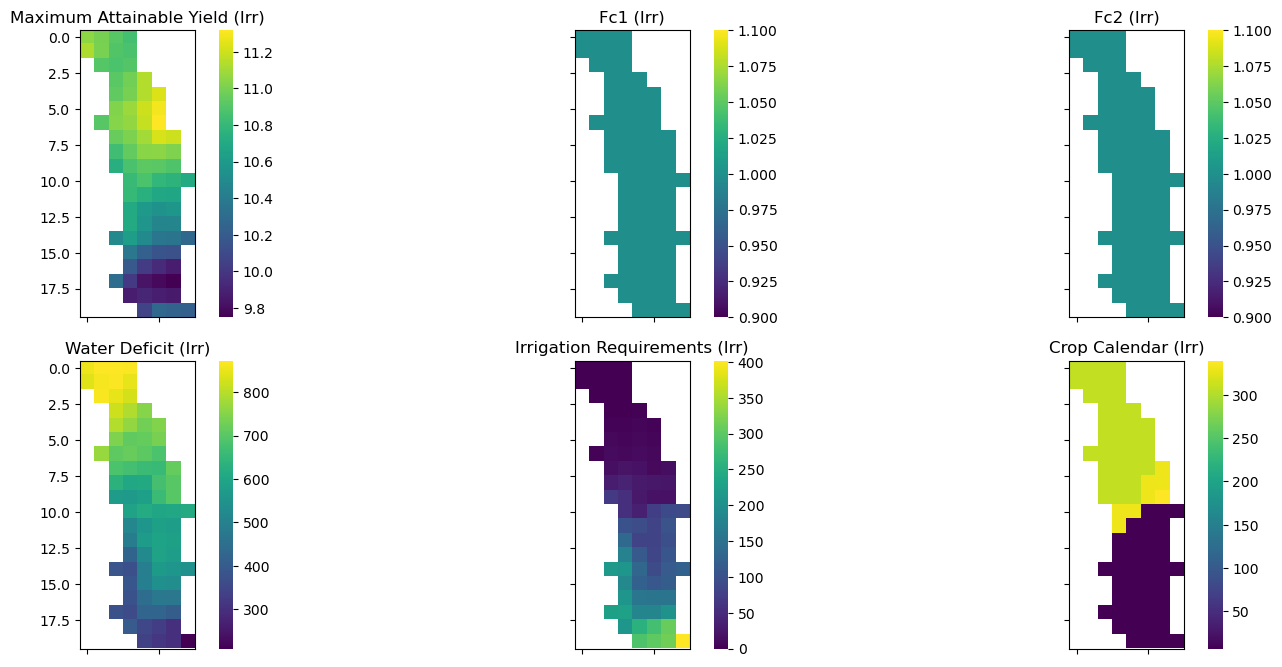

In [9]:
from matplotlib import colormaps, colors

"""Plotting Module II Outputs"""
img_lst = [yld_irr, fc1_irr, fc2_irr, wde_irr, eta_irr, ccd_irr]
label_lst = ['Maximum Attainable Yield (Irr)', 'Fc1 (Irr)', 'Fc2 (Irr)', 'Water Deficit (Irr)',
             'Irrigation Requirements (Irr)', 'Crop Calendar (Irr)']


cmap = colormaps['viridis'].copy()
cmap.set_bad((1, 1, 1, 0))  # transparent for NaN

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(15, 10))
fig.patch.set_alpha(0)

ref_data = np.array(img_lst[0], dtype=float)

val = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        axi = ax[i, j]
        axi.set_facecolor((1, 1, 1, 0))

        if val < len(img_lst):
            # Make background transparent: convert background value (e.g., 0 or -999) to NaN
            data = np.array(img_lst[val], dtype=float)
            background_value = 0  # change to -999 if that's your mask
            data[ref_data == background_value] = np.nan

            # Compute bounds from finite data (exclude NaN)
            vmin = np.nanmin(data) if np.isfinite(data).any() else 0.0
            vmax = np.nanmax(data) if np.isfinite(data).any() else 1.0
            norm = colors.Normalize(vmin=vmin, vmax=vmax)

            im = axi.imshow(data, cmap=cmap, norm=norm, interpolation='nearest')

            # Colorbar with transparent background
            cbar = plt.colorbar(im, ax=axi)
            cbar.ax.set_facecolor((1, 1, 1, 0))
            cbar.outline.set_visible(False)

            axi.set_title(label_lst[val])
        else:
            axi.remove()
        val += 1

plt.tight_layout()


#### Suitability Classes Determination based on Yield


Yield Classification
1.   not suitable (yields between 0% and 20%)
2.   marginally suitable (yields between 20% and 40%)
3.   moderately suitable (yields between 40% and 60%)
4. suitable (yields between 60% and 80%)
5. very suitable (yields are equivalent to 80% or more of the overall maximum yield)



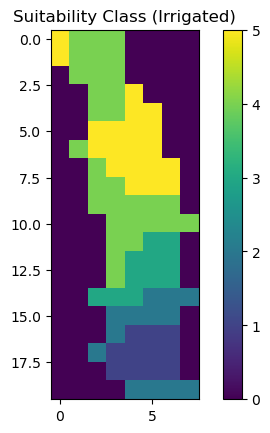

In [10]:
# get classified output of yield
#from pyaez.pyaez_main import classifyFinalYield

yield_map_irr_class = CropSimulation.classifyFinalYield(yld_irr)

'''visualize result'''

"""Classified Yield"""
plt.imshow(yield_map_irr_class, vmin = 0, vmax = 5)
plt.colorbar()
plt.title('Suitability Class (Irrigated)')
plt.show()

#### Saving Module II Irrigated Results

In [11]:
'''save result'''
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_yld_irr_{aez.year}.tif', yld_irr)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_fc1_irr_{aez.year}.tif', fc1_irr)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_fc2_irr_{aez.year}.tif', fc2_irr)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_wde_irr_{aez.year}.tif', wde_irr)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_eta_irr_{aez.year}.tif', eta_irr)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_ccd_irr_{aez.year}.tif', ccd_irr)

## Simulation for Rainfed Conditions

In [12]:
# '''run simulations'''
aez.simulateRainfedCropCycle(start_doy=1, end_doy=365, step_doy=1, leap_year=False)

EXECUTING maize Rainfed Crop Simulation
-------------------------
Crop Type Annuals
-------------------------
Masking				=Activated
Thermal Climate Screening	=Activated
TSUM Screening			=Activated
Permafrost Screening		=Activated
Crop-specific Rule Screening	=Activated
-------------------------
Hibernation Principle		=Deactivated
-------------------------
Done:100.0 %
Rainfed Crop Simulation Completed


Simulation for Sugarcane

##### Outputs from Rainfed Crop Simulation
> Introducing new outputs
1. Crop-specific total water deficit (wde)
2. Crop-specific total irrigation requirements (eta)

In [13]:
yld_rain = aez.getEstimatedYieldRainfed() # Maximum attainable yield
fc1_rain = aez.getThermalReductionFactorRainfed() # Fc1 factor
fc2_rain = aez.getMoistureReductionFactorRainfed() # Fc2 factor
wde_rain = aez.getWDERainfed() # total water deficit
eta_rain = aez.getETARainfed() # total irrigation requirements 
ccd_rain = aez.getOptimumCycleStartDateRainfed() # crop calendar

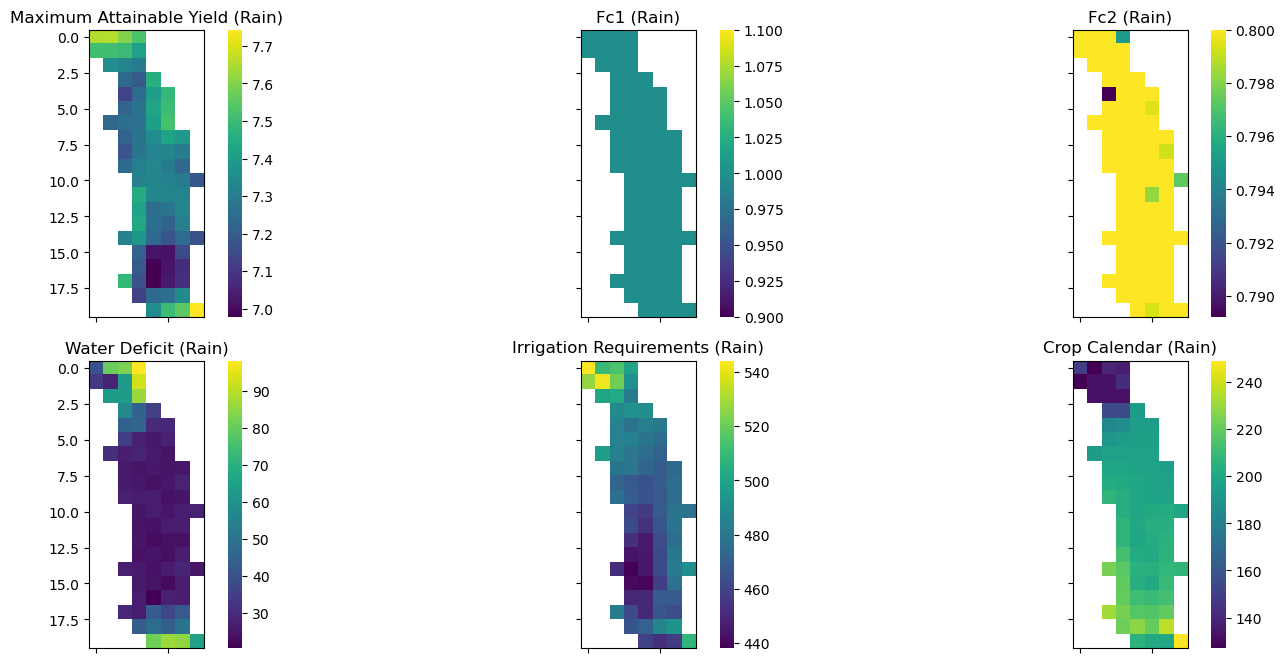

In [14]:
from matplotlib import colormaps, colors

"""Plotting Module II Outputs"""
img_lst = [yld_rain, fc1_rain, fc2_rain, wde_rain, eta_rain, ccd_rain]
label_lst = ['Maximum Attainable Yield (Rain)', 'Fc1 (Rain)', 'Fc2 (Rain)', 'Water Deficit (Rain)',
             'Irrigation Requirements (Rain)', 'Crop Calendar (Rain)']


cmap = colormaps['viridis'].copy()
cmap.set_bad((1, 1, 1, 0))  # transparent for NaN

fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(15, 10))
fig.patch.set_alpha(0)

ref_data = np.array(img_lst[0], dtype=float)

val = 0
for i in range(ax.shape[0]):
    for j in range(ax.shape[1]):
        axi = ax[i, j]
        axi.set_facecolor((1, 1, 1, 0))

        if val < len(img_lst):
            # Make background transparent: convert background value (e.g., 0 or -999) to NaN
            data = np.array(img_lst[val], dtype=float)
            background_value = 0  # change to -999 if that's your mask
            data[ref_data == background_value] = np.nan

            # Compute bounds from finite data (exclude NaN)
            vmin = np.nanmin(data) if np.isfinite(data).any() else 0.0
            vmax = np.nanmax(data) if np.isfinite(data).any() else 1.0
            norm = colors.Normalize(vmin=vmin, vmax=vmax)

            im = axi.imshow(data, cmap=cmap, norm=norm, interpolation='nearest')

            # Colorbar with transparent background
            cbar = plt.colorbar(im, ax=axi)
            cbar.ax.set_facecolor((1, 1, 1, 0))
            cbar.outline.set_visible(False)

            axi.set_title(label_lst[val])
        else:
            axi.remove()
        val += 1

plt.tight_layout()


### Suitability Classes Determination based on Yield


Yield Classification
1.   not suitable (yields between 0% and 20%)
2.   marginally suitable (yields between 20% and 40%)
3.   moderately suitable (yields between 40% and 60%)
4. suitable (yields between 60% and 80%)
5. very suitable (yields are equivalent to 80% or more of the overall maximum yield)



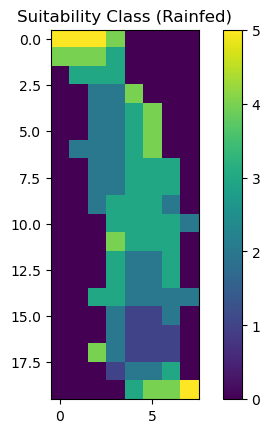

In [15]:
# get classified output of yield
yield_map_rain_class = CropSimulation.classifyFinalYield(yld_rain)

'''visualize result'''

"""Classified Yield"""
plt.imshow(yield_map_rain_class, vmin = 0, vmax = 5)
plt.colorbar()
plt.title('Suitability Class (Rainfed)')
plt.show()

#### Saving Module II Rainfed Results

In [16]:
'''save result'''
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_yld_rain_{aez.year}.tif', yld_rain)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_fc1_rain_{aez.year}.tif', fc1_rain)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_fc2_rain_{aez.year}.tif', fc2_rain)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_wde_rain_{aez.year}.tif', wde_rain)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_eta_rain_{aez.year}.tif', eta_rain)
saveRaster(aez.ref_raster, rf'./data_output/NB2/{aez.country_name}_{aez.crop_name}_ccd_rain_{aez.year}.tif', ccd_rain)

<hr>

### END OF MODULE 2: CROP SIMULATION

<hr>